In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
train_csv = pd.read_csv("/kaggle/input/competitions/titanic/train.csv").set_index("PassengerId")
test_csv = pd.read_csv("/kaggle/input/competitions/titanic/test.csv").set_index("PassengerId")

y = train_csv.Survived
X = train_csv.drop("Survived", axis=1)

X_train,X_valid,y_train,y_valid = train_test_split(X,y,test_size=0.2,random_state=0)

# 取り扱いの難しい特徴量について
"Age","Name","Cabin"の3つについては、それぞれ欠損が多かったり、カテゴリ数が多かったりの理由で取り扱っていなかったので、ここで機械に読み込みやすい形に整えていくことを目指す。

Titanicの生存率において、性別による生存率の差が激しいことから、その逆の結果として

>女性で死亡しやすかった特徴

>男性で生き残りやすかった特徴
>
この2つを重点的に探していく

In [4]:
train_csv[["Age","Name","Cabin"]].head(10)

,Age,Name,Cabin
PassengerId,,,
1,22.0,"Braund, Mr. Owen Harris",NaN
2,38.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",C85
3,26.0,"Heikkinen, Miss. Laina",NaN
4,35.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",C123
5,35.0,"Allen, Mr. William Henry",NaN
6,NaN,"Moran, Mr. James",NaN
7,54.0,"McCarthy, Mr. Timothy J",E46
8,2.0,"Palsson, Master. Gosta Leonard",NaN
9,27.0,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",NaN


# "Age"列の欠損を埋めるために、"Name"列を使用
名前に含まれる敬称”Title"を取り出していく。以下の5つにName列の値を分類していき、敬称別の中央値年齢で"Age"の欠損値を埋めていく

* Master：男児(ほぼ12歳未満)
* Miss：未婚女性(若年層多め)
* Mrs：既婚女性(成人女性)
* Mr：成人男性
* Rare(その他)：サンプル数が少ないものをまとめて扱う

In [5]:
#" "スペースを置いて敬称の前のスペースを示す。また.ピリオドで敬称の終わりを示す
train_csv["Title"] = train_csv["Name"].str.extract(" ([A-Za-z]+)\.",expand = False)

#取り出した敬称を上記5つに分類していく
train_csv["Title"] = train_csv["Title"].replace(["Mlle","Ms"],"Miss")
train_csv["Title"] = train_csv["Title"].replace("Mme","Mrs")
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
train_csv["Title"] = train_csv["Title"].replace(rare_titles,"Rare")

#敬称別の年齢の中央値を算出
Age_median = train_csv.groupby("Title")["Age"].median()
print(Age_median)

#年齢の欠損を、敬称別の中央値の年齢で埋める
train_csv["Age"] = train_csv["Age"].fillna(train_csv.groupby("Title")["Age"].transform("median"))

#Age確認用
print()
print("Age null sum:",train_csv.Age.isnull().sum())

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

Age null sum: 0


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/1959423958.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_csv["Title"] = train_csv["Name"].str.extract(" ([A-Za-z]+)\.",expand = False)


# "Age"について
まず、年齢を3歳ごとに区切り、年齢別の生存率について男性と女性に分けてみていく。(性別による生存率の影響が大きいため、本来の年齢による影響度をある程度純粋に比較したいから)

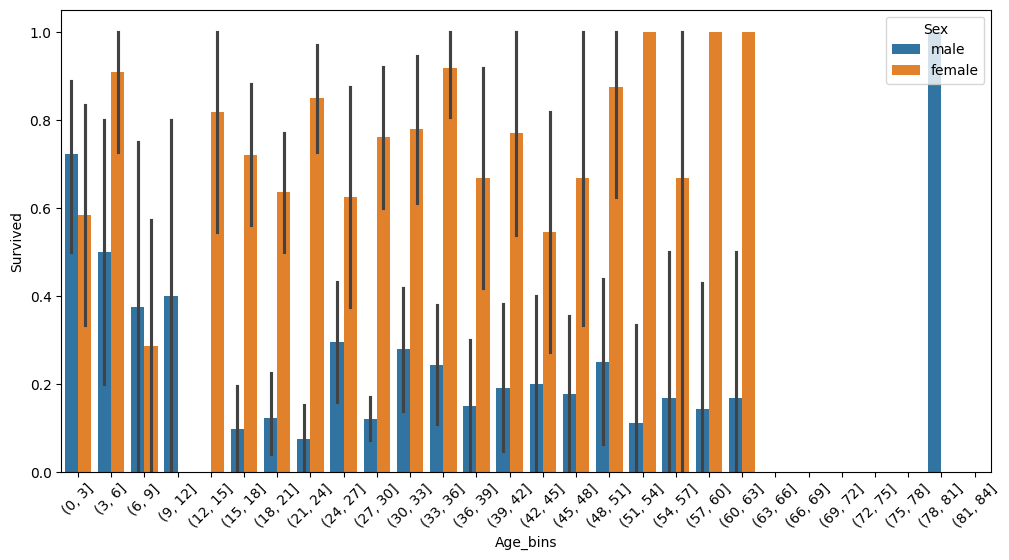

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

bins = range(0,85,3)
train_csv["Age_bins"] = pd.cut(train_csv["Age"],bins)

plt.figure(figsize=(12,6))

sns.barplot(x="Age_bins",y="Survived",data=train_csv,hue="Sex")
plt.xticks(rotation=45) #x軸を見やすくするために斜めに回転
plt.show()

・女性の生存率についてみると、
>0-6歳未満：平均生存率はほかの年代と同程度に高い

>6-12歳未満：平均生存率が極端に低くなっている。
※今回の目的の「女性で死亡率が高い特徴」に合致

>12-48歳未満：信頼区間や生存率が比較的安定して70~80%を維持

>48歳-：平均生存率が80%を超えてくる。極端に高い

・男性の生存率についてみていく
>0-12歳未満：平均生存率はほかの年代と比べて約40%以上と高い。※今回の目的の「男性なのに生存率が高い特徴」に合致

>12-63歳未満：平均生存率は一貫して約10-30%ほど。

>78-81歳：生存率が極端に高いがデータが少ない

* "master”の敬称があるのに、女児にはないことから、当時の時代背景などにより、男児の方が優遇されていたことがうかがえる。このことから、男児(12歳未満)の生存率が高く、救助優先度が高いことが理解できる。
* 女児においては、6歳未満の子供の生存率が高いのは、親が抱きかかえて行動を共にできる範囲の年齢帯であったことではないかと予想できる。6-12歳では、緊急時に抱きかかえながら移動などが厳しく、また先述した男児優先などの背景から、救助優先順位として中程度のランクだったのではと予想される

# "Age","Sex","Survived"を組み合わせた生存可能性の作成
上記から、生存可能性ランクは
1. Sランク(3点)：男性(0-12歳未満)　&　女性(0-6歳未満、48歳以上)
2. Aランク(2点)：男性(無し)　&　女性(12-48歳未満)
3. Bランク(1点)：男性(無し)　&　女性(6-12歳未満)
4. Cランク(0点)：男性(12-85歳すべて)　&　女性(無し)

このように上から順に救助されたと考える。また、このデータは順序が生存予測に影響するため、大小関係を機械に学習させやすいように点数で値を作る

In [7]:
#各ランクの点数によって分ける条件式
condition_3points = (
    ((train_csv["Sex"]=="male") & (train_csv["Age"]<12)) |
    ((train_csv["Sex"]=="female") & ((train_csv["Age"]<6) |
                                    (train_csv["Age"]>=48)))
)

condition_2points = (
    (train_csv["Sex"]=="female") & (train_csv["Age"]>=12) & (train_csv["Age"]<48)
)

condition_1point = (
    (train_csv["Sex"]=="female") & (train_csv["Age"]>=6) & (train_csv["Age"]<12)
)

#条件リストと、それに対応する点数のリスト作成
conditions = [condition_3points,condition_2points,condition_1point]
points = [3,2,1]

#新しい特徴量として"surv_rank"を作成、デフォルトで0点上記の条件以外の部分
train_csv["surv_rank"] = np.select(conditions,points,default=0)

print(train_csv["surv_rank"].dtype)
print(train_csv["surv_rank"].value_counts())

int64
surv_rank
0    537
2    254
3     89
1     11
Name: count, dtype: int64


# "Cabin"について
Cabinは欠損がとても多い特徴量。ゆえに、値の有無自体が情報となる。また、cabinの頭文字は部屋やデッキの位置を表し、生存率に直結する。

* "has_cabin"：cabinの値の有無。データがある=名簿あり=１等客室のため生存率高めが予想される
* "cabin_deck：デッキによって生存率が変わる。救命ボートへの近さや、デッキごとの救助の優先などが変わるため

上記2つの特徴量を作っていく

In [8]:
#"has_cabin"を作っていく
train_csv["has_cabin"] = train_csv["Cabin"].notnull().astype(int)
#notnull()でブール値を作り、astype(int)で0,1の整数に変換していく

train_csv.groupby("has_cabin")["Survived"].mean()

has_cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

”Cabin"のデータがあるだけで、生存率が2倍以上になっているため、この特徴量は使えそうだ。

In [9]:
#"cabin_deck"について考える
#"Cabin"の頭文字を抽出。欠損値は”Unknown"に変換
train_csv["cabin_deck"] = train_csv["Cabin"].str[0].fillna("Unknown")

print(train_csv.groupby("cabin_deck")["Survived"].mean())
print()
print(train_csv["cabin_deck"].value_counts())

cabin_deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

cabin_deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


ここで、"cabin_deck"の「G」「T」については、サンプル数が少なすぎるため、過学習を防ぐという観点からも「Unknown」の方に振り分けてもよさそうである。

In [10]:
#cabi_deckの"G","T"を”Unknown"に振り分ける
train_csv.loc[train_csv["cabin_deck"].isin(["G","T"]),"cabin_deck"] = "Unknown"

# 新特徴量まとめ

* "Name"→"Age"の欠損値埋めの補助、"Title"の作成
* "Age"→”surb_rank"の作成
* "Cabin"→"has_cabin","cabin_deck"の作成

In [11]:
train_csv.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_bins,surv_rank,has_cabin,cabin_deck
PassengerId,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,"(21, 24]",0,0,Unknown
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"(36, 39]",2,1,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,"(24, 27]",2,0,Unknown
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,"(33, 36]",2,1,C
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,"(33, 36]",0,0,Unknown
